### **Symulacja konwolucji**

In [29]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
#przykładowy obraz (5x5)
image = np.array([
    [1, 2, 3, 0, 1],
    [0, 1, 2, 3, 1],
    [1, 2, 1, 0, 0],
    [0, 1, 3, 1, 2],
    [2, 0, 1, 3, 1]
])

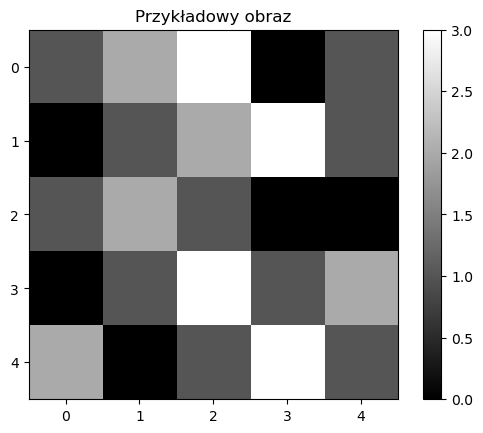

In [31]:
plt.imshow(image, cmap='gray')
plt.title("Przykładowy obraz")
plt.colorbar()
plt.show()

In [6]:
#kernel do wykrywania pionowych krawędzi
kernel = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1]
])

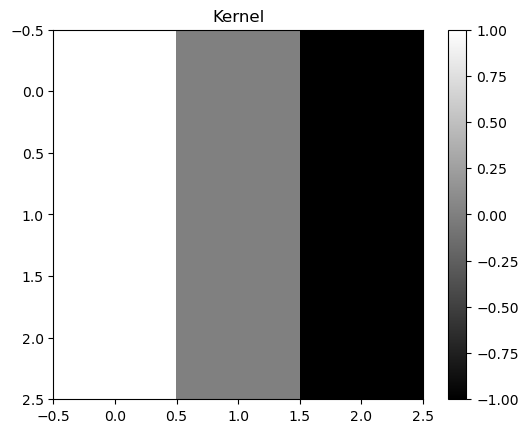

In [35]:
plt.imshow(kernel, cmap='gray')
plt.title("Kernel")
plt.colorbar()
plt.show()

In [37]:
#wymiary
k = kernel.shape[0]
output_size = image.shape[0] - k + 1
output_size

3

In [39]:
#wynik
output = np.zeros((output_size, output_size))

print("Obraz wejściowy:\n", image)
print("\nKernel:\n", kernel)

Obraz wejściowy:
 [[1 2 3 0 1]
 [0 1 2 3 1]
 [1 2 1 0 0]
 [0 1 3 1 2]
 [2 0 1 3 1]]

Kernel:
 [[ 1  0 -1]
 [ 1  0 -1]
 [ 1  0 -1]]


In [41]:
print("\n--- Symulacja konwolucji ---\n")
#przesuwanie kernela
for i in range(output_size):
    for j in range(output_size):
        
        # wycinamy fragment
        patch = image[i:i+k, j:j+k]
        
        # mnożenie element po elemencie
        multiplied = patch * kernel
        
        # suma
        value = np.sum(multiplied)
        output[i, j] = value
        
        # pokaz kroków
        print(f"Pozycja ({i},{j})")
        print("Fragment obrazu:\n", patch)
        print("Po mnożeniu:\n", multiplied)
        print("Suma =", value)
        print("-" * 40)


--- Symulacja konwolucji ---

Pozycja (0,0)
Fragment obrazu:
 [[1 2 3]
 [0 1 2]
 [1 2 1]]
Po mnożeniu:
 [[ 1  0 -3]
 [ 0  0 -2]
 [ 1  0 -1]]
Suma = -4
----------------------------------------
Pozycja (0,1)
Fragment obrazu:
 [[2 3 0]
 [1 2 3]
 [2 1 0]]
Po mnożeniu:
 [[ 2  0  0]
 [ 1  0 -3]
 [ 2  0  0]]
Suma = 2
----------------------------------------
Pozycja (0,2)
Fragment obrazu:
 [[3 0 1]
 [2 3 1]
 [1 0 0]]
Po mnożeniu:
 [[ 3  0 -1]
 [ 2  0 -1]
 [ 1  0  0]]
Suma = 4
----------------------------------------
Pozycja (1,0)
Fragment obrazu:
 [[0 1 2]
 [1 2 1]
 [0 1 3]]
Po mnożeniu:
 [[ 0  0 -2]
 [ 1  0 -1]
 [ 0  0 -3]]
Suma = -5
----------------------------------------
Pozycja (1,1)
Fragment obrazu:
 [[1 2 3]
 [2 1 0]
 [1 3 1]]
Po mnożeniu:
 [[ 1  0 -3]
 [ 2  0  0]
 [ 1  0 -1]]
Suma = 0
----------------------------------------
Pozycja (1,2)
Fragment obrazu:
 [[2 3 1]
 [1 0 0]
 [3 1 2]]
Po mnożeniu:
 [[ 2  0 -1]
 [ 1  0  0]
 [ 3  0 -2]]
Suma = 3
----------------------------------------
P

In [43]:
print("\nWynik końcowy (feature map):\n", output)


Wynik końcowy (feature map):
 [[-4.  2.  4.]
 [-5.  0.  3.]
 [-2. -1.  2.]]


Interpretacja:
- duże dodatnie wartości → wykryta krawędź (np. lewa jasna, prawa ciemna)
- duże ujemne → krawędź odwrotna
- blisko 0 → brak krawędzi

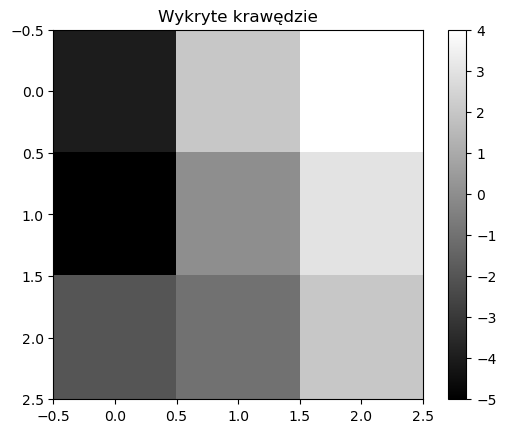

In [46]:
import matplotlib.pyplot as plt

plt.imshow(output, cmap='gray')
plt.title("Wykryte krawędzie")
plt.colorbar()
plt.show()